<a href="https://colab.research.google.com/github/pinballsurgeon/deluxo_adjacency/blob/main/Gemini_20Hz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

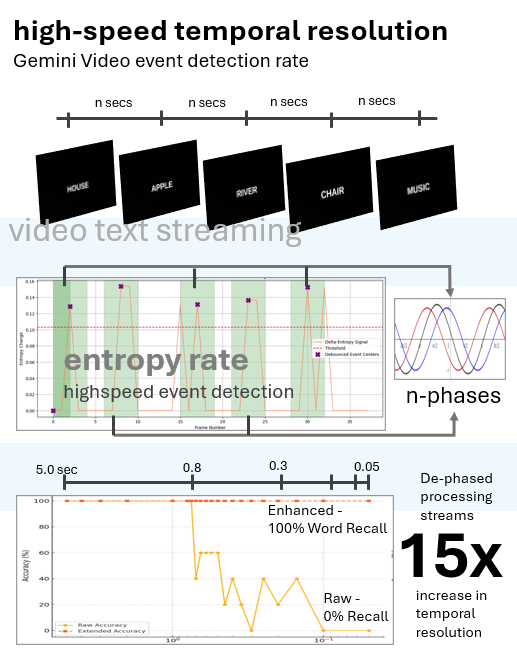

In [ ]:
!pip install -U -q "google"
!pip install -U -q "google.genai"

import os
from google.colab import userdata
from google.colab import drive
import numpy as np
from PIL import Image, ImageDraw, ImageFont
from moviepy.editor import ImageClip, concatenate_videoclips, ColorClip
import cv2

from scipy.stats import entropy
import matplotlib.pyplot as plt
import pandas as pd

from scipy.signal import find_peaks

from skimage.metrics import structural_similarity as ssim

import google.generativeai as genai
from google.colab import userdata

import time





In [10]:

# word list
WORDS_TO_DISPLAY = ["APPLE", "HOUSE", "RIVER", "CHAIR", "MUSIC"]

# list of per/word duration seconds
TEST_DURATIONS = [5, 4, 3, 2, 1, 0.8, 0.5, 0.3]
TEST_DURATIONS = [0.7, 0.6, 0.4]
TEST_DURATIONS = [0.75, 0.65, 0.55, 0.45]
TEST_DURATIONS = [0.2, 0.25, 0.35]
TEST_DURATIONS = [0.1, 0.15, 0.05]

# video settings
VIDEO_WIDTH = 1920
VIDEO_HEIGHT = 1080
VIDEO_FPS = 30
BACKGROUND_COLOR = (0, 0, 0)
TEXT_COLOR = (255, 255, 255)
FONT_SIZE = 150

# drive output path
OUTPUT_FOLDER_PATH = "/content/drive/MyDrive/WordTestVideos_Final"

# drive folder
if not os.path.exists(OUTPUT_FOLDER_PATH):
    os.makedirs(OUTPUT_FOLDER_PATH)
    print(f"Created folder: {OUTPUT_FOLDER_PATH}")
else:
    print(f"Output folder already exists: {OUTPUT_FOLDER_PATH}")

Output folder already exists: /content/drive/MyDrive/WordTestVideos_Final


In [11]:

# pillow text images
def create_text_image(text, width, height, bg_color, text_color, font_size):

    # blank image
    img = Image.new('RGB', (width, height), color=bg_color)
    draw = ImageDraw.Draw(img)

    # default font
    try:
        font = ImageFont.truetype("LiberationSans-Bold.ttf", font_size)
    except IOError:
        print("Default font not found, using basic font.")
        font = ImageFont.load_default()

    # centering
    _, _, text_width, text_height = draw.textbbox((0,0), text, font=font)
    x = (width - text_width) / 2
    y = (height - text_height) / 2

    # draw text
    draw.text((x, y), text, font=font, fill=text_color)

    # numpy array
    return np.array(img)

# frame generation
for duration in TEST_DURATIONS:

    print(f"\nvideo for {duration} second duration...")
    clips_for_this_video = []


    for word in WORDS_TO_DISPLAY:
        # 1. create  image
        image_array = create_text_image(word, VIDEO_WIDTH, VIDEO_HEIGHT, BACKGROUND_COLOR, TEXT_COLOR, FONT_SIZE)

        # 2. convert to video clip
        image_clip = ImageClip(image_array).set_duration(duration)

        # 3. add word clip
        clips_for_this_video.append(image_clip)

    # combine all clips
    final_clip = concatenate_videoclips(clips_for_this_video)

    # output filename
    duration_str = str(duration).replace('.', '_')
    output_filename = f"WordTest_{duration_str}_seconds.mp4"
    full_output_path = os.path.join(OUTPUT_FOLDER_PATH, output_filename)

    # write video to drive
    print(f"   -> Saving file: {output_filename} ...")
    try:
        final_clip.write_videofile(
            full_output_path,
            fps=VIDEO_FPS,
            codec='libx264',
            logger=None
        )
        print(f" saved")
    except Exception as e:
        print(f" eRROR: {e}")


print(f"saved to drive '{OUTPUT_FOLDER_PATH}' folder.")


video for 0.1 second duration...
   -> Saving file: WordTest_0_1_seconds.mp4 ...
 saved

video for 0.15 second duration...
   -> Saving file: WordTest_0_15_seconds.mp4 ...
 saved

video for 0.05 second duration...
   -> Saving file: WordTest_0_05_seconds.mp4 ...
 saved
saved to drive '/content/drive/MyDrive/WordTestVideos_Final' folder.


In [2]:
# check directory for mp4s
directory_path = OUTPUT_FOLDER_PATH
file_info_dict = {}

#  directory exists
if os.path.exists(directory_path):
    for item_name in os.listdir(directory_path):
        full_path = os.path.join(directory_path, item_name)

        if os.path.isfile(full_path):
            file_info_dict[item_name] = full_path

    print("File information dictionary created:")
    for file_name, file_path in file_info_dict.items():
        print(f"File Name: {file_name}, Full Path: {file_path}")
else:
    print(f"Directory not found or not accessible: {directory_path}")

File information dictionary created:
File Name: WordTest_5_seconds.mp4, Full Path: /content/drive/MyDrive/WordTestVideos_Final/WordTest_5_seconds.mp4
File Name: WordTest_4_seconds.mp4, Full Path: /content/drive/MyDrive/WordTestVideos_Final/WordTest_4_seconds.mp4
File Name: WordTest_3_seconds.mp4, Full Path: /content/drive/MyDrive/WordTestVideos_Final/WordTest_3_seconds.mp4
File Name: WordTest_2_seconds.mp4, Full Path: /content/drive/MyDrive/WordTestVideos_Final/WordTest_2_seconds.mp4
File Name: WordTest_1_seconds.mp4, Full Path: /content/drive/MyDrive/WordTestVideos_Final/WordTest_1_seconds.mp4
File Name: WordTest_0_8_seconds.mp4, Full Path: /content/drive/MyDrive/WordTestVideos_Final/WordTest_0_8_seconds.mp4
File Name: WordTest_0_5_seconds.mp4, Full Path: /content/drive/MyDrive/WordTestVideos_Final/WordTest_0_5_seconds.mp4
File Name: WordTest_0_3_seconds.mp4, Full Path: /content/drive/MyDrive/WordTestVideos_Final/WordTest_0_3_seconds.mp4
File Name: WordTest_0_7_seconds.mp4, Full Path:

Processing video: /content/drive/MyDrive/WordTestVideos_Final/WordTest_0_05_seconds.mp4
Video Properties: 38 frames, 30.00 FPS

Processing complete. Calculated entropy for 38 frames.


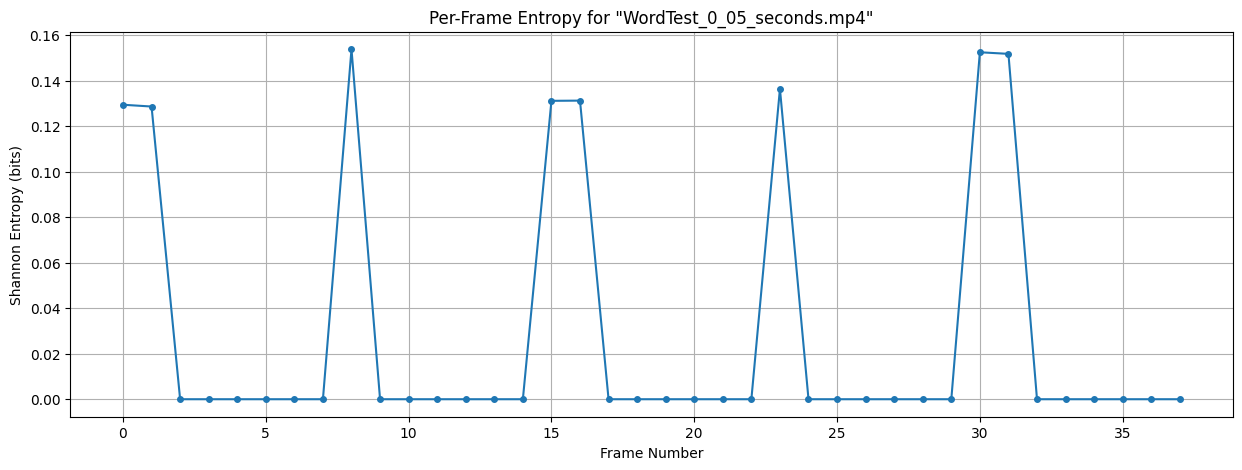

In [3]:

target_video_name = 'WordTest_0_05_seconds.mp4'
video_path = file_info_dict.get(target_video_name)

entropy_values = []

# Check video path
if not video_path:
    print(f"Error: Could not find '{target_video_name}' in the file dictionary.")
else:
    print(f"processing video: {video_path}")

    # video
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print("Error: Could not open video file.")
    else:
        fps = cap.get(cv2.CAP_PROP_FPS)
        frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        print(f"vid properties: {frame_count} frames, {fps:.2f} FPS")

        # iterate through each frame
        while True:
            ret, frame = cap.read()

            if not ret:
                break

            #  grayscale for simpler entropy calculation
            gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

            # histogram of the grayscale pixel intensities
            hist = cv2.calcHist([gray_frame], [0], None, [256], [0, 256])

            # normalize to get probabilities
            prob_dist = hist / hist.sum()

            # shannon entropy from probability distribution
            frame_entropy = entropy(prob_dist, base=2)

            # store entropy value
            entropy_values.append(frame_entropy[0]) # entropy() returns an array, so we take the first element

        cap.release()
        print(f"\nProcessing complete. Calculated entropy for {len(entropy_values)} frames.")

# vizualiuze raw entropy data
if entropy_values:
    plt.figure(figsize=(15, 5))
    plt.plot(entropy_values, marker='o', linestyle='-', markersize=4)
    plt.title(f'Per-Frame Entropy for "{target_video_name}"')
    plt.xlabel('Frame Number')
    plt.ylabel('Shannon Entropy (bits)')
    plt.grid(True)
    plt.show()

--- Running Event-Centric Segmentation Engine ---
Found 7 raw candidate peaks at frames: [ 2  8 15 17 23 30 32]
Debouncing peaks within a 2 frame distance...
Found 6 debounced, distinct event centers: [0, np.int64(2), np.int64(8), np.int64(17), np.int64(23), np.int64(30)]

--- FINAL EVENT-CENTRIC SEGMENTS ---
   Start Frame  End Frame  Event Center  Duration (frames)
0            0          2             0                  3
1            0          4             2                  5
2            6         10             8                  5
3           15         19            17                  5
4           21         25            23                  5
5           28         32            30                  5


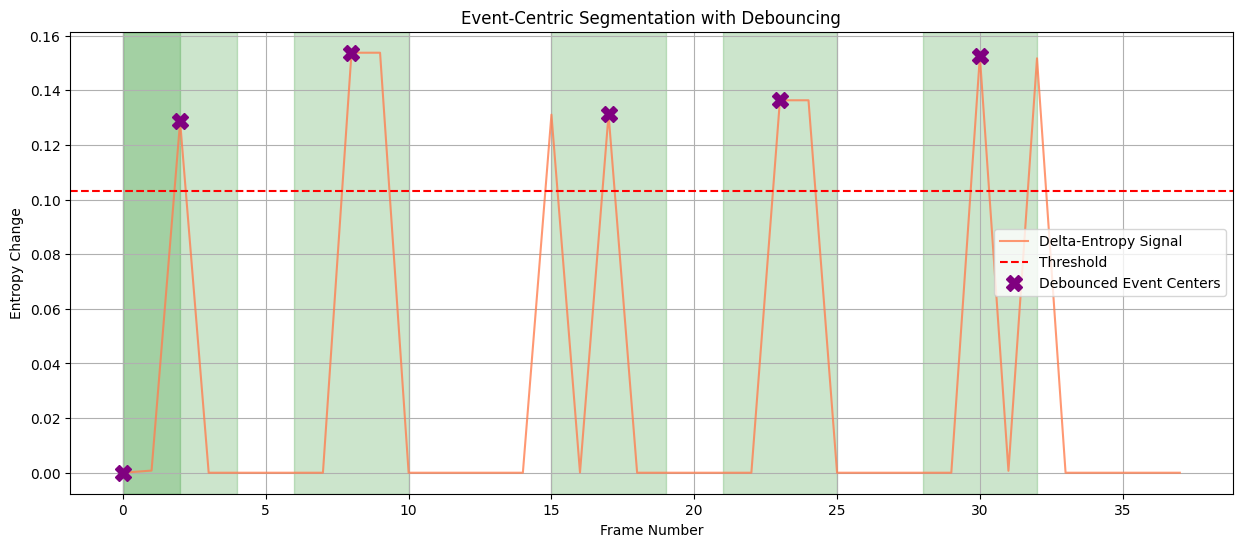

In [4]:

def find_event_centric_segments(entropy_values, video_fps):

    # signal Prep
    if not entropy_values:
        print("Error: Entropy values list is empty.")
        return pd.DataFrame()
    delta_entropy = np.abs(np.diff(entropy_values, prepend=entropy_values[0]))
    total_frames = len(entropy_values)

    # peak detection
    threshold = ( delta_entropy.mean() + 2 * delta_entropy.std() ) / 1.5
    all_peaks, properties = find_peaks(delta_entropy, height=threshold)
    print(f"found {len(all_peaks)} raw candidate peaks at frames: {all_peaks}")

    # debouncing
    min_frame_distance = max(2, int(0.1 * video_fps / 4))
    print(f"debouncing peaks within a {min_frame_distance} frame distance...")

    if len(all_peaks) < 2:
        debounced_peaks = all_peaks
    else:
        # sort peaks by their strength
        sorted_peak_indices = np.argsort(properties['peak_heights'])[::-1]
        strongest_peaks = all_peaks[sorted_peak_indices]

        debounced_peaks = []
        claimed_frames = np.zeros(total_frames, dtype=bool)

        for peak in strongest_peaks:
            if not claimed_frames[peak]:
                debounced_peaks.append(peak)
                start = max(0, peak - min_frame_distance)
                end = min(total_frames, peak + min_frame_distance + 1)
                claimed_frames[start:end] = True

    # initial state event
    if entropy_values[0] > 0.01 and not any(p < min_frame_distance for p in debounced_peaks):
        debounced_peaks.append(0)

    debounced_peaks = sorted(debounced_peaks)
    print(f"found {len(debounced_peaks)} debounced, distinct event centers: {debounced_peaks}")

    # debounced peak center
    expansion_radius = 2
    segments = []
    for peak_center in debounced_peaks:
        start_frame = max(0, peak_center - expansion_radius)
        end_frame = min(total_frames - 1, peak_center + expansion_radius)
        segments.append((start_frame, end_frame))

    # result df
    if not segments:
        print("Warning: No segments were formed.")
        return pd.DataFrame()

    segment_df = pd.DataFrame(segments, columns=['Start Frame', 'End Frame'])
    segment_df['Event Center'] = debounced_peaks
    segment_df['Duration (frames)'] = segment_df['End Frame'] - segment_df['Start Frame'] + 1

    print(segment_df)


    plt.figure(figsize=(15, 6))
    plt.plot(delta_entropy, label='Delta-Entropy Signal', color='coral', alpha=0.8)
    plt.axhline(y=threshold, color='r', linestyle='--', label=f'Threshold')
    plt.plot(debounced_peaks, delta_entropy[debounced_peaks], "X", color='purple', markersize=12, label='Debounced Event Centers')
    for index, row in segment_df.iterrows():
        plt.axvspan(row['Start Frame'], row['End Frame'], color='green', alpha=0.2, label='_nolegend_')
    plt.title('Event-Centric Segmentation with Debouncing')
    plt.xlabel('Frame Number')
    plt.ylabel('Entropy Change')
    plt.legend()
    plt.grid(True)
    plt.show()

    return segment_df

segment_df = find_event_centric_segments(entropy_values, fps)

In [5]:


# frames of context to add before and after each segment
CONTEXT_PADDING_FRAMES = 5

# output
output_dir_A = 'stream_A_frames'
output_dir_B = 'stream_B_frames'
os.makedirs(output_dir_A, exist_ok=True)
os.makedirs(output_dir_B, exist_ok=True)
cap = cv2.VideoCapture(video_path)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# counters
stream_a_frame_count = 0
stream_b_frame_count = 0

# iterate throug heach event
for index, segment in segment_df.iterrows():
    if index % 2 == 0:
        target_dir = output_dir_A
        stream_name = "A"
    else:
        target_dir = output_dir_B
        stream_name = "B"

    # boundries
    padded_start = max(0, segment['Start Frame'] - CONTEXT_PADDING_FRAMES)
    padded_end = min(total_frames, segment['End Frame'] + CONTEXT_PADDING_FRAMES)

    print(f"  processing segment {index} for stream {stream_name}: frames {padded_start}-{padded_end}")

    cap.set(cv2.CAP_PROP_POS_FRAMES, padded_start)

    for frame_num in range(padded_start, padded_end):
        ret, frame = cap.read()
        if not ret:
            break

        file_name = f"segment_{index}_frame_{frame_num:04d}.jpg"
        file_path = os.path.join(target_dir, file_name)
        cv2.imwrite(file_path, frame)

        # increment counter
        if stream_name == "A":
            stream_a_frame_count += 1
        else:
            stream_b_frame_count += 1

cap.release()

Created output directories: 'stream_A_frames' and 'stream_B_frames'

Starting phased extraction process...
  Processing Segment 0 for Stream A: Frames 0-7
  Processing Segment 1 for Stream B: Frames 0-9
  Processing Segment 2 for Stream A: Frames 1-15
  Processing Segment 3 for Stream B: Frames 10-24
  Processing Segment 4 for Stream A: Frames 16-30
  Processing Segment 5 for Stream B: Frames 23-37

--- Extraction Complete ---
Stream A: Saved 35 frames to the 'stream_A_frames' directory.
Stream B: Saved 37 frames to the 'stream_B_frames' directory.


In [6]:
# ref
cap_ref = cv2.VideoCapture(video_path)
ret_ref, blank_frame_bgr = cap_ref.read()
cap_ref.release()

if not ret_ref:
    print("ERROR: Could not read the first frame to use as a blank reference.")
else:
    # gray
    blank_frame_gray = cv2.cvtColor(blank_frame_bgr, cv2.COLOR_BGR2GRAY)
    print("reference frame captured successfully.")


def normalize_segment_to_duration(original_frames_bgr, target_duration_secs, fps):

    if not original_frames_bgr:
        return []

    target_frame_count = int(target_duration_secs * fps)


    lowest_ssim = 1.0
    peak_stability_frame = original_frames_bgr[0]

    for frame_bgr in original_frames_bgr:
        frame_gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
        score = ssim(blank_frame_gray, frame_gray)

        if score < lowest_ssim:
            lowest_ssim = score
            peak_stability_frame = frame_bgr

    normalized_frames_pil = []


    for frame_bgr in original_frames_bgr:
        rgb_frame = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
        normalized_frames_pil.append(Image.fromarray(rgb_frame))


    frames_to_add = target_frame_count - len(original_frames_bgr)
    if frames_to_add > 0:
        peak_frame_rgb = cv2.cvtColor(peak_stability_frame, cv2.COLOR_BGR2RGB)
        peak_frame_pil = Image.fromarray(peak_frame_rgb)

        for _ in range(frames_to_add):
            normalized_frames_pil.append(peak_frame_pil)

    return normalized_frames_pil


print("\n--- Running Verification Test ---")
try:
    first_segment = segment_df.iloc[0]
    start_frame = first_segment['Start Frame']
    end_frame = first_segment['End Frame']

    cap_test = cv2.VideoCapture(video_path)
    cap_test.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
    original_segment_frames = []
    for _ in range(start_frame, end_frame + 1):
        ret_test, frame_test = cap_test.read()
        if not ret_test: break
        original_segment_frames.append(frame_test)
    cap_test.release()

    print(f"testing with Segment 0: {len(original_segment_frames)} original frames (from frame {start_frame} to {end_frame})")

    # normalize to duration
    normalized_frames = normalize_segment_to_duration(original_segment_frames, target_duration_secs=0.8, fps=fps)


    if len(normalized_frames) == int(0.8 * fps):
        print(f"   Normalized frame count: {len(normalized_frames)} (Target: {int(0.8*fps)})")
    else:
        print(f"   Expected: {int(0.8*fps)}, Got: {len(normalized_frames)}")

except Exception as e:
    print(f"An error occurred during verification: {e}")

Capturing blank reference frame...
Reference frame captured successfully.

--- Running Verification Test ---
Testing with Segment 0: 3 original frames (from frame 0 to 2)

--- VERIFICATION RESULT ---
✅ SUCCESS: The function correctly normalized the segment.
   Original frame count: 3
   Normalized frame count: 24 (Target: 24)


In [8]:

# gemini keys
try:
    api_key = userdata.get('GEMINI_API_KEY')
    genai.configure(api_key=api_key)
    model = genai.GenerativeModel('gemini-2.5-flash')
    print("Gemini client configured successfully.")
except Exception as e:
    print(f"API Key Error: {e} - try to populate GEMINI_API_KEY in colab secrets")

structured_results = []

# iteratet hrough segemetns
for index, segment in segment_df.iterrows():
    start_time = time.time()
    start_frame = segment['Start Frame']
    end_frame = segment['End Frame']

    print(f"\n--- processing Segment {index} (Original Frames {start_frame}-{end_frame}) ---")

    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
    original_segment_frames = []
    for _ in range(start_frame, end_frame + 1):
        ret, frame = cap.read()
        if not ret: break
        original_segment_frames.append(frame)
    cap.release()

    # fail
    if not original_segment_frames:
        print("  [Failed] Could not extract frames for this segment.")
        result_details = {
            'Word': 'ERROR_NO_FRAMES', 'Segment Index': index, 'Original Frames': f"{start_frame}-{end_frame}",
            'Normalized Duration (s)': 0, 'Processing Time (s)': 0, 'Gemini Raw': 'N/A'
        }
        structured_results.append(result_details)
        continue

    # normalize the frames to 0.8 seconds ---
    print(f"  normalizing {len(original_segment_frames)} original frames to 0.8 seconds...")
    normalized_frames_pil = normalize_segment_to_duration(
        original_frames_bgr=original_segment_frames,
        target_duration_secs=0.8,
        fps=fps
    )


    prompt = """you are a silent, hyper-focused Optical Character Recognition (OCR) engine.
Yyur task is to analyze the following sequence of frames and identify the single word present.
The word may be held statically for a long time. Focus on the clearest representation.
Your entire response must be ONLY the single word you identify, in lowercase."""

    # api call
    try:
        response = model.generate_content([prompt] + normalized_frames_pil)
        raw_word = response.text.strip().lower()
        print(f"  [Success] Gemini identified word: '{raw_word}'")
        gemini_raw_text = response.text.strip()

    except Exception as e:
        print(f"  [Failed] An error occurred during Gemini API call: {e}")
        raw_word = "ERROR_API_CALL"
        gemini_raw_text = str(e)

    end_time = time.time()
    processing_time = round(end_time - start_time, 2)

    result_details = {
        'Word': raw_word,
        'Segment Index': index,
        'Original Frames': f"{start_frame}-{end_frame}",
        'Normalized Duration (s)': 0.8,
        'Processing Time (s)': processing_time,
        'Gemini Raw': gemini_raw_text
    }
    structured_results.append(result_details)

results_df = pd.DataFrame(structured_results).set_index('Segment Index')
word_list = results_df['Word'].unique().tolist()

print(word_list)

Gemini client configured successfully.

Initializing UPGRADED sequential analysis with Temporal Normalization...

--- Processing Segment 0 (Original Frames 0-2) ---
  Normalizing 3 original frames to 0.8 seconds...
  Normalization complete. Total frames for analysis: 24
  Sending normalized sequence to Gemini... (waiting for response)
  [Success] Gemini identified word: 'apple'

--- Processing Segment 1 (Original Frames 0-4) ---
  Normalizing 5 original frames to 0.8 seconds...
  Normalization complete. Total frames for analysis: 24
  Sending normalized sequence to Gemini... (waiting for response)
  [Success] Gemini identified word: 'apple'

--- Processing Segment 2 (Original Frames 6-10) ---
  Normalizing 5 original frames to 0.8 seconds...
  Normalization complete. Total frames for analysis: 24
  Sending normalized sequence to Gemini... (waiting for response)
  [Success] Gemini identified word: 'house'

--- Processing Segment 3 (Original Frames 15-19) ---
  Normalizing 5 original fra